# Hospital Readmission Risk Analysis

**Author:** Davis Rapp  
**Date:** February 2026  
**Data Source:** [UCI Diabetes 130-US Hospitals](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008)

Predicting 30-day hospital readmissions using patient encounter data from 130 US hospitals.

**Goal:** Identify high-risk patients to optimize post-discharge care and reduce preventable readmissions.

**Data:** 101,766 patient encounters with 50 features including demographics, diagnoses, medications, and prior utilization.

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

df = pd.read_csv("../data/raw/diabetic_data.csv")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Shape: 101,766 rows × 50 columns


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Target Variable

The `readmitted` column has three values:
- `NO` — not readmitted
- `>30` — readmitted after 30 days
- `<30` — readmitted within 30 days (our target)

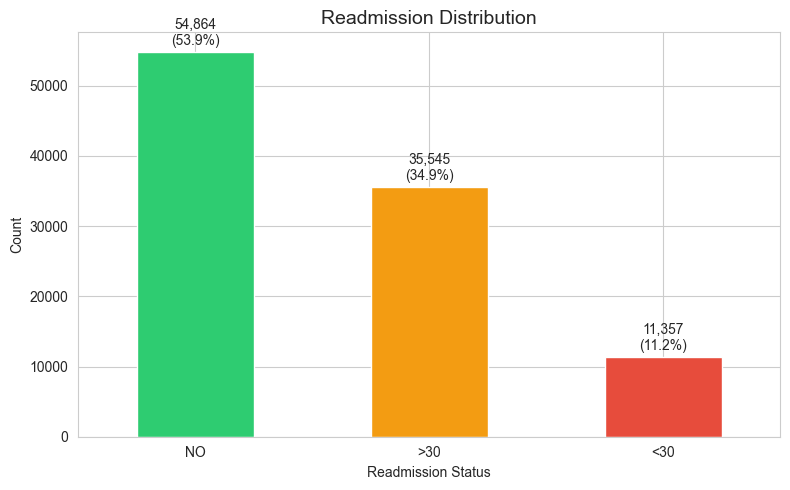

In [60]:
# Target distribution
fig, ax = plt.subplots(figsize=(8, 5))
df["readmitted"].value_counts().plot(kind="bar", ax=ax, color=["#2ecc71", "#f39c12", "#e74c3c"])
ax.set_title("Readmission Distribution", fontsize=14)
ax.set_xlabel("Readmission Status")
ax.set_ylabel("Count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for i, v in enumerate(df["readmitted"].value_counts()):
    ax.text(i, v + 1000, f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center")

plt.tight_layout()
plt.show()

**Key insight:** Only 11% of encounters result in readmission within 30 days. This class imbalance will need to be addressed during modeling.

## Missing Values

The dataset uses "?" to represent missing values.

In [61]:
missing = df.isnull().sum() + (df == "?").sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Columns with missing values:\n")
for col, count in missing.items():
    pct = count / len(df) * 100
    print(f"{col}: {count:,} ({pct:.1f}%)")

Columns with missing values:

weight: 98,569 (96.9%)
max_glu_serum: 96,420 (94.7%)
A1Cresult: 84,748 (83.3%)
medical_specialty: 49,949 (49.1%)
payer_code: 40,256 (39.6%)
race: 2,273 (2.2%)
diag_3: 1,423 (1.4%)
diag_2: 358 (0.4%)
diag_1: 21 (0.0%)


**Decisions:**
- `weight` — 97% missing → drop
- `max_glu_serum` — 95% missing → drop  
- `A1Cresult` — 83% missing → drop
- `medical_specialty` — 49% missing → keep as "Unknown"
- `payer_code` — 40% missing → keep as "Unknown"
- `race` — 2% missing → keep as "Unknown"

## Demographics

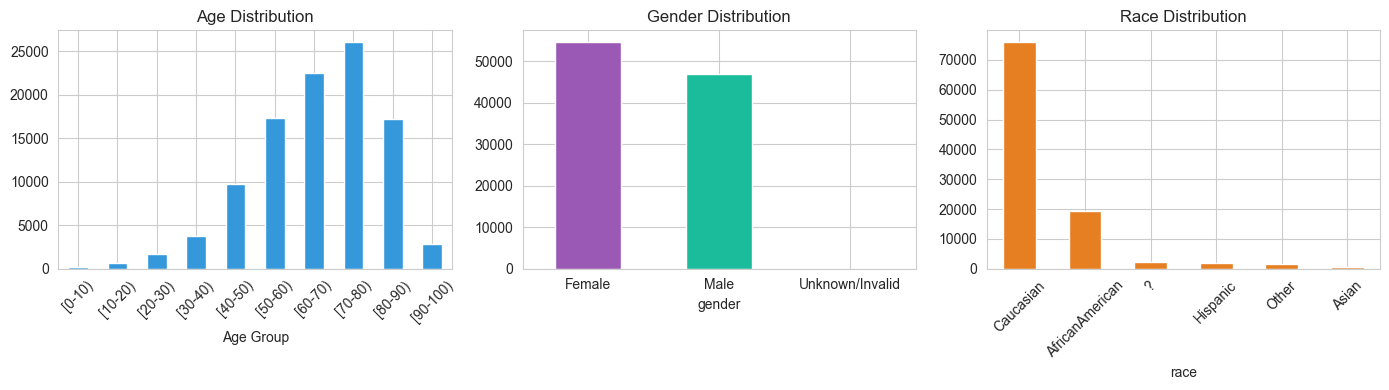

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Age distribution
df["age"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#3498db")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age Group")
axes[0].tick_params(axis='x', rotation=45)

# Gender distribution
df["gender"].value_counts().plot(kind="bar", ax=axes[1], color=["#9b59b6", "#1abc9c"])
axes[1].set_title("Gender Distribution")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

# Race distribution
df["race"].value_counts().plot(kind="bar", ax=axes[2], color="#e67e22")
axes[2].set_title("Race Distribution")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Clinical Variables

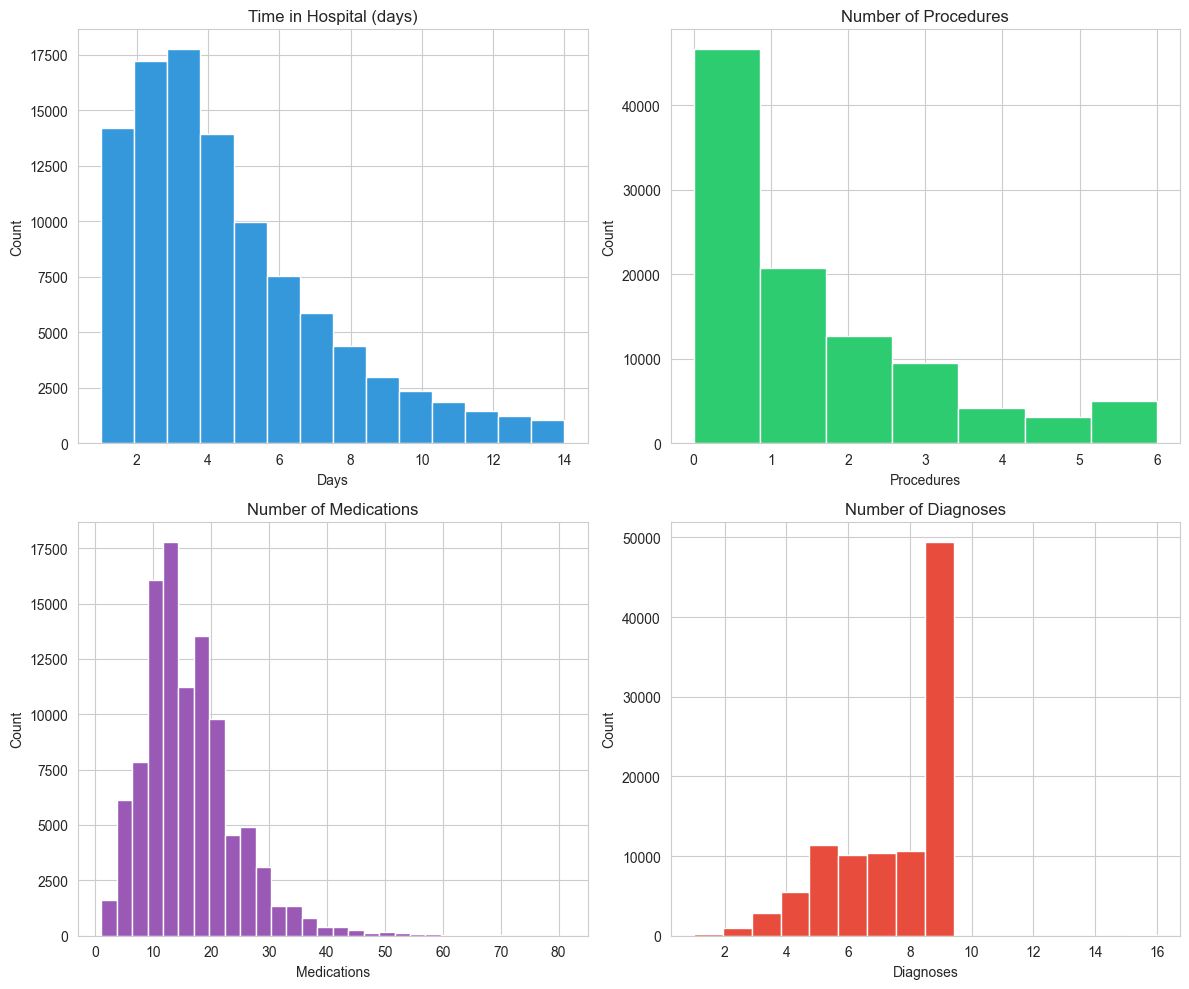

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Time in hospital
axes[0, 0].hist(df["time_in_hospital"], bins=14, color="#3498db", edgecolor="white")
axes[0, 0].set_title("Time in Hospital (days)")
axes[0, 0].set_xlabel("Days")
axes[0, 0].set_ylabel("Count")

# Number of procedures
axes[0, 1].hist(df["num_procedures"], bins=7, color="#2ecc71", edgecolor="white")
axes[0, 1].set_title("Number of Procedures")
axes[0, 1].set_xlabel("Procedures")
axes[0, 1].set_ylabel("Count")

# Number of medications
axes[1, 0].hist(df["num_medications"], bins=30, color="#9b59b6", edgecolor="white")
axes[1, 0].set_title("Number of Medications")
axes[1, 0].set_xlabel("Medications")
axes[1, 0].set_ylabel("Count")

# Number of diagnoses
axes[1, 1].hist(df["number_diagnoses"], bins=16, color="#e74c3c", edgecolor="white")
axes[1, 1].set_title("Number of Diagnoses")
axes[1, 1].set_xlabel("Diagnoses")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## Prior Utilization

How many times did the patient visit the hospital before this encounter?

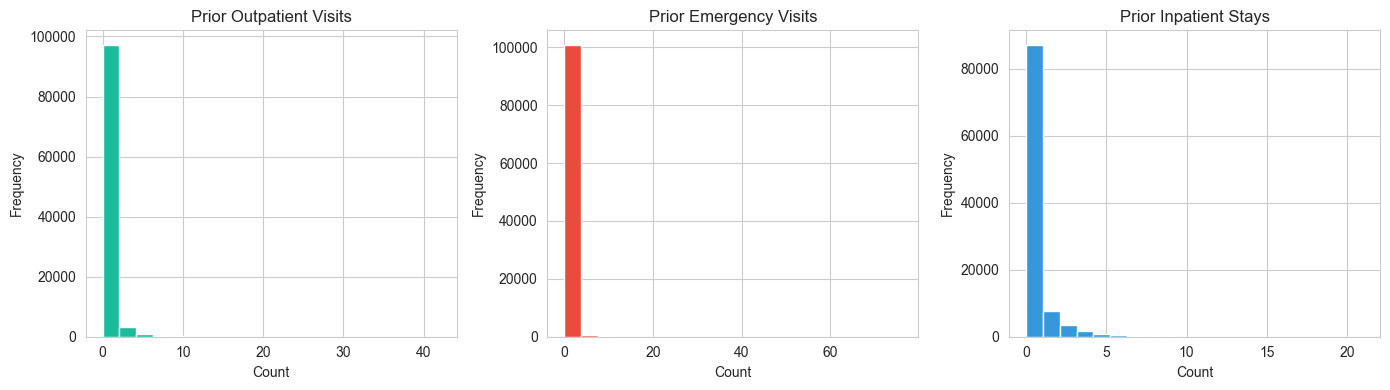

Prior utilization summary:
       number_outpatient  number_emergency  number_inpatient
count           101766.0          101766.0          101766.0
mean                 0.4               0.2               0.6
std                  1.3               0.9               1.3
min                  0.0               0.0               0.0
25%                  0.0               0.0               0.0
50%                  0.0               0.0               0.0
75%                  0.0               0.0               1.0
max                 42.0              76.0              21.0


In [64]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

prior_cols = ["number_outpatient", "number_emergency", "number_inpatient"]
colors = ["#1abc9c", "#e74c3c", "#3498db"]
titles = ["Prior Outpatient Visits", "Prior Emergency Visits", "Prior Inpatient Stays"]

for i, col in enumerate(prior_cols):
    axes[i].hist(df[col], bins=20, color=colors[i], edgecolor="white")
    axes[i].set_title(titles[i])
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Summary stats
print("Prior utilization summary:")
print(df[prior_cols].describe().round(1))

## Readmission Rates by Key Variables

Now let's see what actually correlates with 30-day readmission.

In [65]:
# Create binary target for easier analysis
df["readmit_30"] = (df["readmitted"] == "<30").astype(int)

print(f"Overall 30-day readmission rate: {df['readmit_30'].mean()*100:.1f}%")

Overall 30-day readmission rate: 11.2%


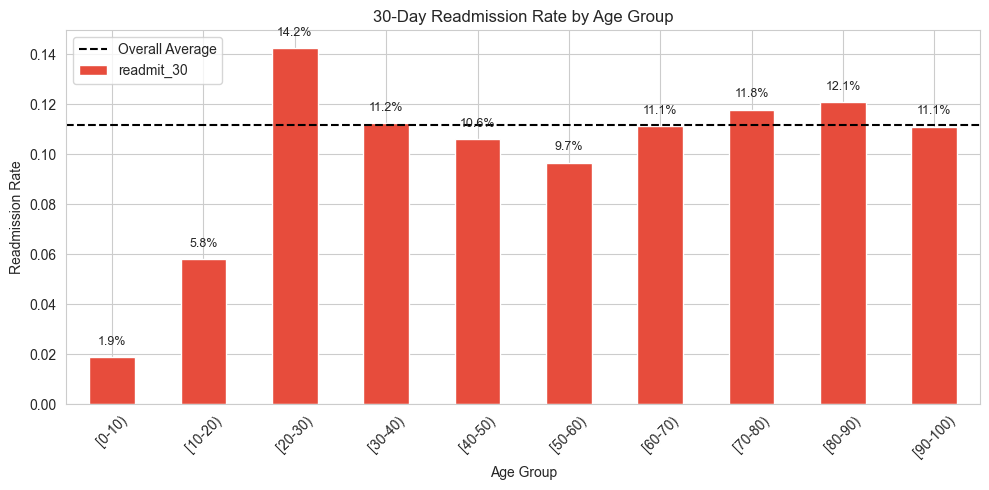

In [66]:
# Readmission rate by age
readmit_by_age = df.groupby("age")["readmit_30"].mean().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
readmit_by_age.plot(kind="bar", ax=ax, color="#e74c3c")
ax.set_title("30-Day Readmission Rate by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Readmission Rate")
ax.axhline(y=df["readmit_30"].mean(), color="black", linestyle="--", label="Overall Average")
ax.legend()
ax.tick_params(axis='x', rotation=45)

# Add percentage labels
for i, v in enumerate(readmit_by_age):
    ax.text(i, v + 0.005, f"{v*100:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

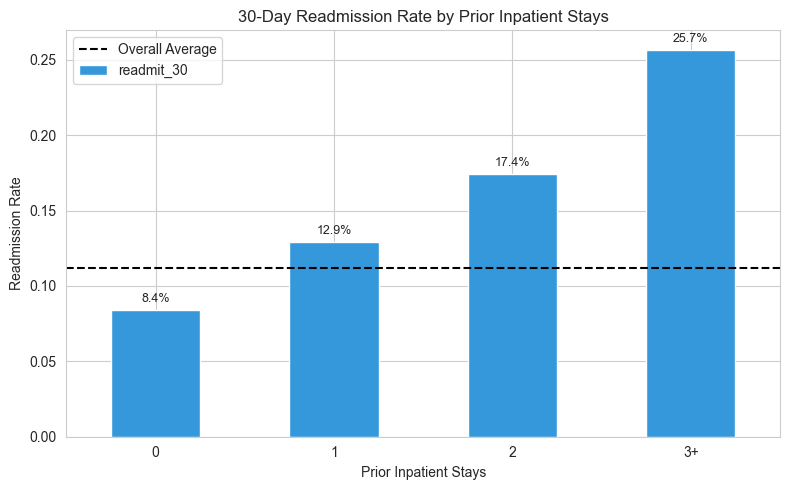

In [67]:
# Readmission rate by number of prior inpatient stays
df["inpatient_group"] = pd.cut(df["number_inpatient"], bins=[-1, 0, 1, 2, 100], labels=["0", "1", "2", "3+"])

readmit_by_inpatient = df.groupby("inpatient_group")["readmit_30"].mean()

fig, ax = plt.subplots(figsize=(8, 5))
readmit_by_inpatient.plot(kind="bar", ax=ax, color="#3498db")
ax.set_title("30-Day Readmission Rate by Prior Inpatient Stays")
ax.set_xlabel("Prior Inpatient Stays")
ax.set_ylabel("Readmission Rate")
ax.axhline(y=df["readmit_30"].mean(), color="black", linestyle="--", label="Overall Average")
ax.legend()
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for i, v in enumerate(readmit_by_inpatient):
    ax.text(i, v + 0.005, f"{v*100:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

**Key Finding:** Patients with prior inpatient stays have significantly higher readmission risk. This is intuitive — sicker patients use more hospital services.

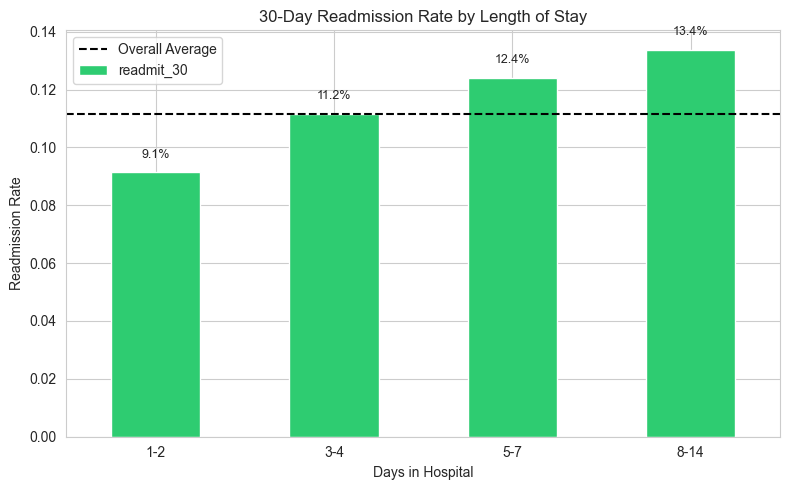

In [68]:
# Readmission rate by time in hospital
df["los_group"] = pd.cut(df["time_in_hospital"], bins=[0, 2, 4, 7, 14], labels=["1-2", "3-4", "5-7", "8-14"])

readmit_by_los = df.groupby("los_group")["readmit_30"].mean()

fig, ax = plt.subplots(figsize=(8, 5))
readmit_by_los.plot(kind="bar", ax=ax, color="#2ecc71")
ax.set_title("30-Day Readmission Rate by Length of Stay")
ax.set_xlabel("Days in Hospital")
ax.set_ylabel("Readmission Rate")
ax.axhline(y=df["readmit_30"].mean(), color="black", linestyle="--", label="Overall Average")
ax.legend()
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for i, v in enumerate(readmit_by_los):
    ax.text(i, v + 0.005, f"{v*100:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

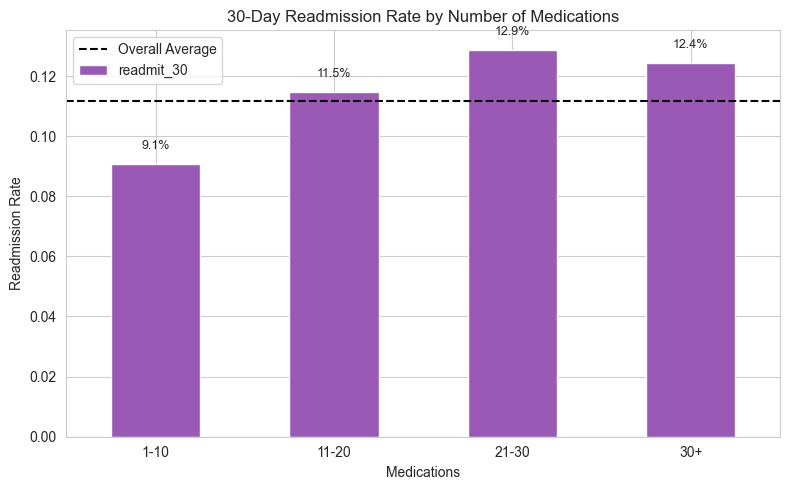

In [69]:
# Readmission rate by number of medications
df["med_group"] = pd.cut(df["num_medications"], bins=[0, 10, 20, 30, 100], labels=["1-10", "11-20", "21-30", "30+"])

readmit_by_meds = df.groupby("med_group")["readmit_30"].mean()

fig, ax = plt.subplots(figsize=(8, 5))
readmit_by_meds.plot(kind="bar", ax=ax, color="#9b59b6")
ax.set_title("30-Day Readmission Rate by Number of Medications")
ax.set_xlabel("Medications")
ax.set_ylabel("Readmission Rate")
ax.axhline(y=df["readmit_30"].mean(), color="black", linestyle="--", label="Overall Average")
ax.legend()
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for i, v in enumerate(readmit_by_meds):
    ax.text(i, v + 0.005, f"{v*100:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## Discharge Disposition

Where patients go after discharge may indicate risk level.

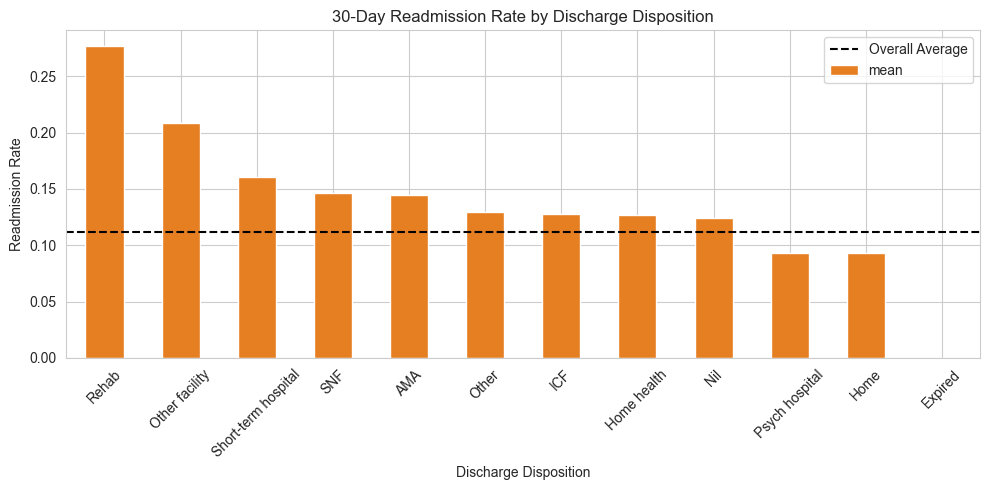

In [70]:
# Map discharge codes to readable labels (most common ones)
discharge_map = {
    1: "Home",
    2: "Short-term hospital",
    3: "SNF",
    4: "ICF",
    5: "Other facility",
    6: "Home health",
    7: "AMA",
    11: "Expired",
    18: "Nil",
    22: "Rehab",
    23: "Long-term care",
    25: "Psych hospital"
}

df["discharge_label"] = df["discharge_disposition_id"].map(discharge_map).fillna("Other")

# Readmission by discharge type
readmit_by_discharge = df.groupby("discharge_label")["readmit_30"].agg(["mean", "count"])
readmit_by_discharge = readmit_by_discharge[readmit_by_discharge["count"] > 500]  # Filter small groups
readmit_by_discharge = readmit_by_discharge.sort_values("mean", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
readmit_by_discharge["mean"].plot(kind="bar", ax=ax, color="#e67e22")
ax.set_title("30-Day Readmission Rate by Discharge Disposition")
ax.set_xlabel("Discharge Disposition")
ax.set_ylabel("Readmission Rate")
ax.axhline(y=df["readmit_30"].mean(), color="black", linestyle="--", label="Overall Average")
ax.legend()
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Insulin and Diabetes Medications

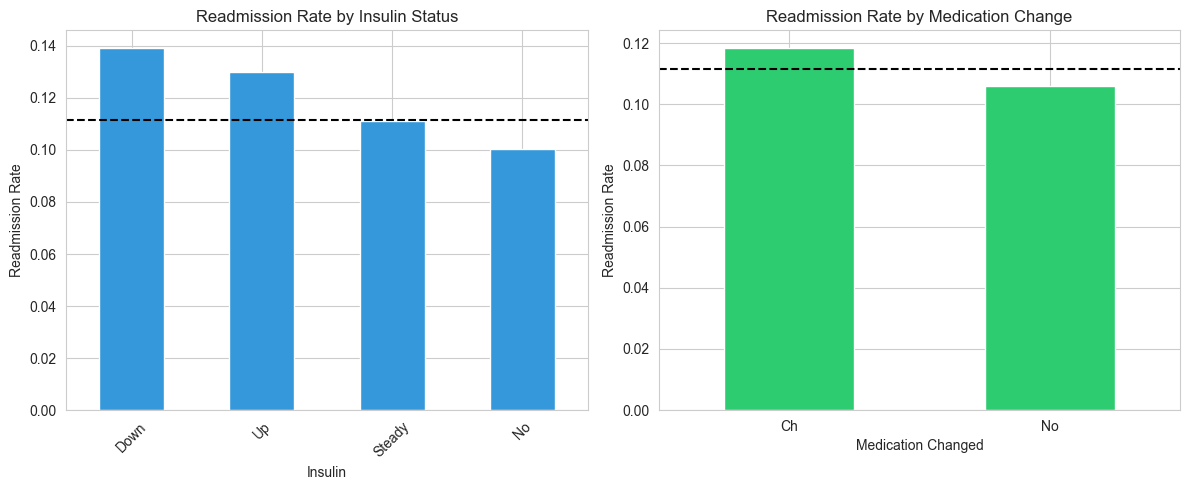

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Insulin
readmit_by_insulin = df.groupby("insulin")["readmit_30"].mean().sort_values(ascending=False)
readmit_by_insulin.plot(kind="bar", ax=axes[0], color="#3498db")
axes[0].set_title("Readmission Rate by Insulin Status")
axes[0].set_xlabel("Insulin")
axes[0].set_ylabel("Readmission Rate")
axes[0].axhline(y=df["readmit_30"].mean(), color="black", linestyle="--")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

# Diabetes medication change
readmit_by_change = df.groupby("change")["readmit_30"].mean()
readmit_by_change.plot(kind="bar", ax=axes[1], color="#2ecc71")
axes[1].set_title("Readmission Rate by Medication Change")
axes[1].set_xlabel("Medication Changed")
axes[1].set_ylabel("Readmission Rate")
axes[1].axhline(y=df["readmit_30"].mean(), color="black", linestyle="--")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## Hospital Variation

Even with anonymized IDs, we can see if readmission rates vary significantly by hospital.

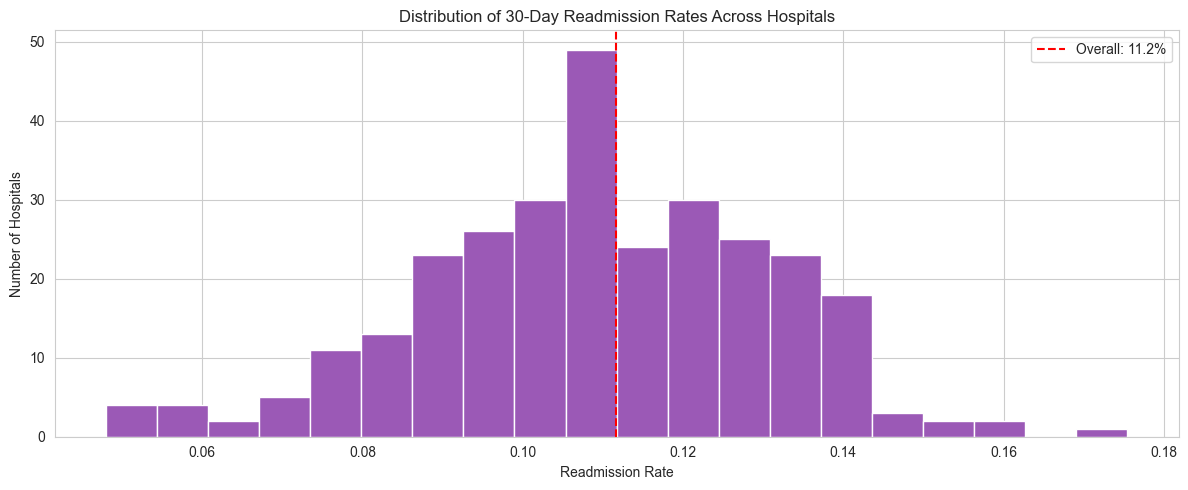

Hospital readmission rates range from 4.8% to 17.5%


In [72]:
# Note: hospital ID is embedded in encounter_id (first few digits)
# Let's look at variation across the dataset using admission_source as a proxy

# Get hospital-level stats (using first 3 chars of encounter as pseudo-hospital)
df["hospital_proxy"] = df["encounter_id"].astype(str).str[:3]

hospital_stats = df.groupby("hospital_proxy").agg(
    encounters=("encounter_id", "count"),
    readmit_rate=("readmit_30", "mean")
).reset_index()

# Filter to hospitals with enough data
hospital_stats = hospital_stats[hospital_stats["encounters"] >= 100]

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(hospital_stats["readmit_rate"], bins=20, color="#9b59b6", edgecolor="white")
ax.set_title("Distribution of 30-Day Readmission Rates Across Hospitals")
ax.set_xlabel("Readmission Rate")
ax.set_ylabel("Number of Hospitals")
ax.axvline(x=df["readmit_30"].mean(), color="red", linestyle="--", label=f"Overall: {df['readmit_30'].mean()*100:.1f}%")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Hospital readmission rates range from {hospital_stats['readmit_rate'].min()*100:.1f}% to {hospital_stats['readmit_rate'].max()*100:.1f}%")

## Summary of Key Findings

| Factor | Impact on Readmission |
|--------|----------------------|
| Prior inpatient stays | Strong positive — more prior stays = higher risk |
| Number of medications | Moderate positive — more meds = higher risk |
| Length of stay | Moderate positive — longer stays = higher risk |
| Age | Slight positive — older patients have higher risk |
| Discharge to SNF/rehab | Higher risk than discharge to home |

These findings align with clinical intuition: sicker patients (more meds, longer stays, prior admissions) are more likely to be readmitted.

## Next Steps

1. **Data Cleaning:** Handle missing values, encode categorical variables
2. **Feature Engineering:** Create risk indicators based on findings above
3. **Modeling:** Build classification model to predict 30-day readmission
4. **Intervention Tiers:** Segment patients into Low/Medium/High risk for care prioritization